In [28]:
%pip install requests pandas matplotlib seaborn

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [19]:
API_KEY = "130bcc0bff253a31560ac066207da0e4"  # Replace with your OpenWeatherMap key
CITY = "Pune"
UNITS = "metric"

In [20]:
url = "https://api.openweathermap.org/data/2.5/forecast"
params = {"q": CITY, "appid": API_KEY, "units": UNITS}
response = requests.get(url, params=params, timeout=20)
response.raise_for_status()
weather = response.json()

location = weather["city"]
rows = []
for item in weather["list"]:
    rows.append({
        "datetime": item["dt_txt"],
        "temperature": item["main"]["temp"],
        "humidity": item["main"]["humidity"],
        "wind_speed": item["wind"]["speed"],
        "precipitation": item.get("rain", {}).get("3h", 0.0),
        "latitude": location["coord"]["lat"],
        "longitude": location["coord"]["lon"]
    })

df = pd.DataFrame(rows)
print(f"Retrieved {len(df)} forecast records for {location['name']}, {location['country']}.")
df.head()

Retrieved 40 forecast records for Pune, IN.


,datetime,temperature,humidity,wind_speed,precipitation,latitude,longitude
0,2026-09-22 12:00:00,26.59,56,4.33,4.42,18.5196,73.8553
1,2026-09-22 15:00:00,26.15,78,3.12,5.49,18.5196,73.8553
2,2026-09-22 18:00:00,24.43,95,2.97,0.99,18.5196,73.8553
3,2026-09-22 21:00:00,24.00,95,2.91,1.26,18.5196,73.8553
4,2026-09-23 00:00:00,23.38,94,2.52,0.49,18.5196,73.8553


In [21]:
# Clean and prepare the forecast data
numeric_columns = ["temperature", "humidity", "wind_speed", "precipitation"]
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(subset=["datetime", *numeric_columns]).copy()
df["date"] = df["datetime"].dt.date

# Model the main weather statistics and daily averages
daily_summary = df.groupby("date", as_index=False).agg(
    average_temperature=("temperature", "mean"),
    minimum_temperature=("temperature", "min"),
    maximum_temperature=("temperature", "max"),
    average_humidity=("humidity", "mean"),
    total_precipitation=("precipitation", "sum"),
    average_wind_speed=("wind_speed", "mean")
)

print("Cleaned records:", len(df))
print("Overall statistics:")
print(df[numeric_columns].agg(["mean", "min", "max"]).round(2))
print("\nDaily summary:")
daily_summary.round(2)

Cleaned records: 40
Overall statistics:
      temperature  humidity  wind_speed  precipitation
mean        24.78     81.25        3.84           0.72
min         19.51     54.00        2.26           0.00
max         32.50     95.00        6.07           5.49

Daily summary:


,date,average_temperature,minimum_temperature,maximum_temperature,average_humidity,total_precipitation,average_wind_speed
0,2026-09-22,25.29,24.00,26.59,81.00,12.16,3.33
1,2026-09-23,26.09,23.38,32.50,84.00,10.55,3.55
2,2026-09-24,24.82,21.72,29.00,80.12,5.62,4.05
3,2026-09-25,24.17,21.33,28.41,84.00,0.00,4.18
4,2026-09-26,23.85,20.22,28.56,82.12,0.33,3.89
5,2026-09-27,24.66,19.51,29.15,71.00,0.00,3.70


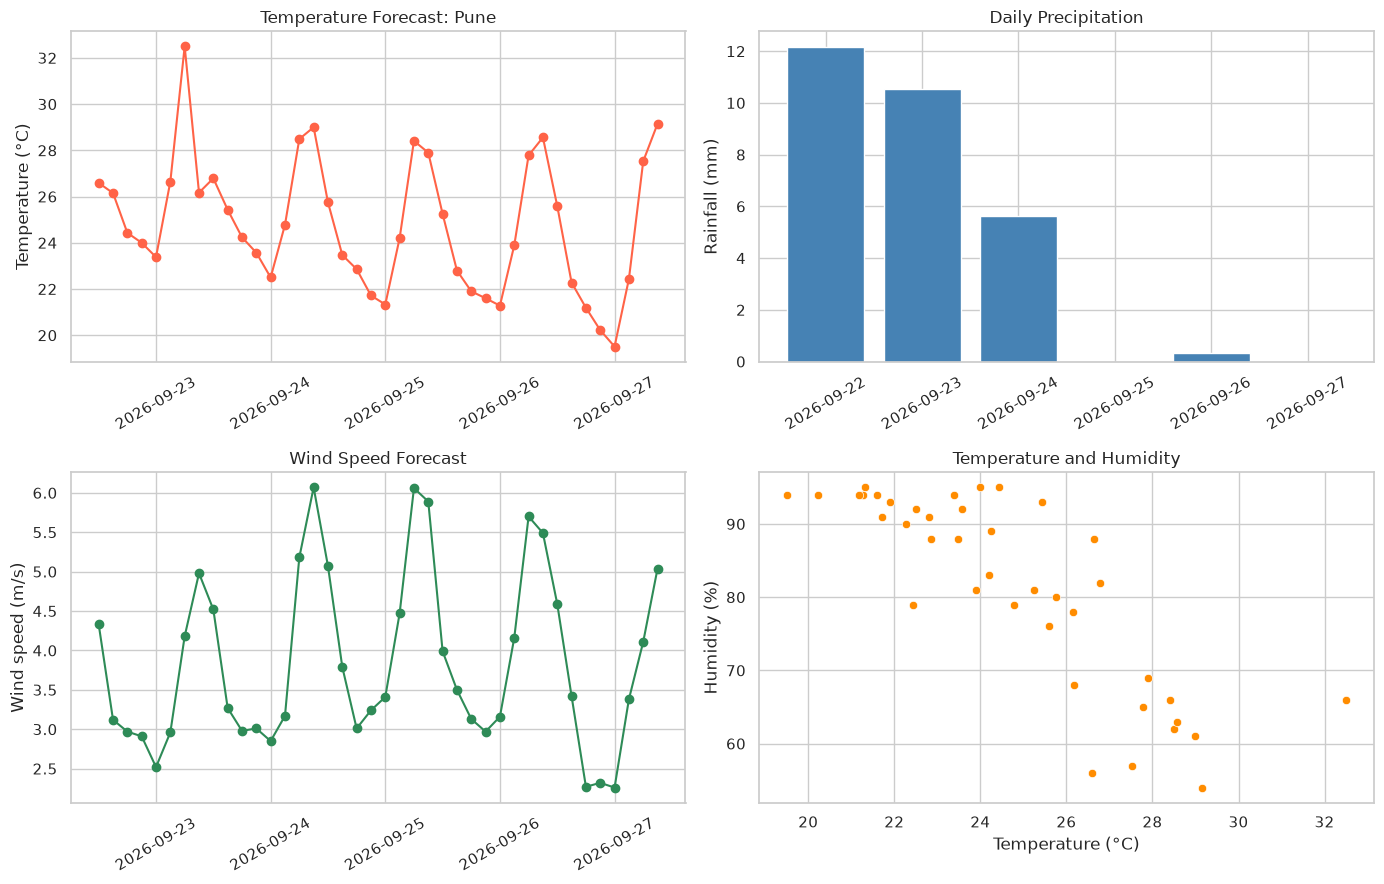

Correlation matrix:
               temperature  humidity  wind_speed  precipitation
temperature           1.00     -0.83        0.76           0.28
humidity             -0.83      1.00       -0.81          -0.23
wind_speed            0.76     -0.81        1.00           0.08
precipitation         0.28     -0.23        0.08           1.00


In [22]:
# Visualize temperature, precipitation, wind, and humidity relationships
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(df["datetime"], df["temperature"], marker="o", color="tomato")
axes[0, 0].set_title(f"Temperature Forecast: {CITY}")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].bar(daily_summary["date"].astype(str), daily_summary["total_precipitation"], color="steelblue")
axes[0, 1].set_title("Daily Precipitation")
axes[0, 1].set_ylabel("Rainfall (mm)")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].plot(df["datetime"], df["wind_speed"], marker="o", color="seagreen")
axes[1, 0].set_title("Wind Speed Forecast")
axes[1, 0].set_ylabel("Wind speed (m/s)")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.scatterplot(data=df, x="temperature", y="humidity", ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Temperature and Humidity")
axes[1, 1].set_xlabel("Temperature (°C)")
axes[1, 1].set_ylabel("Humidity (%)")

plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(df[numeric_columns].corr().round(2))

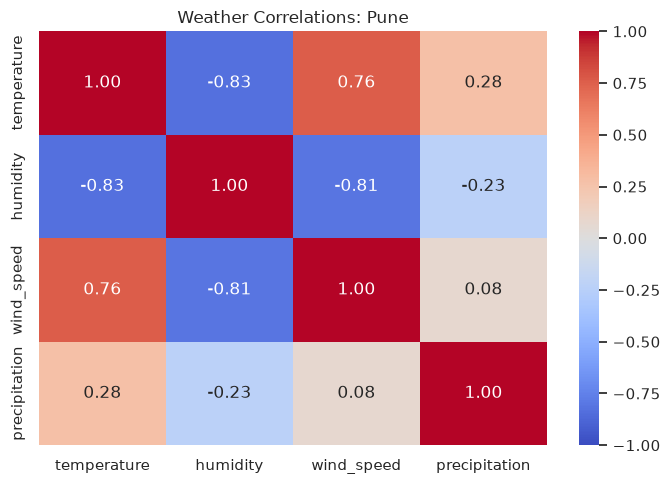

In [23]:
# Heatmap of relationships between weather attributes
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title(f"Weather Correlations: {CITY}")
plt.tight_layout()
plt.show()

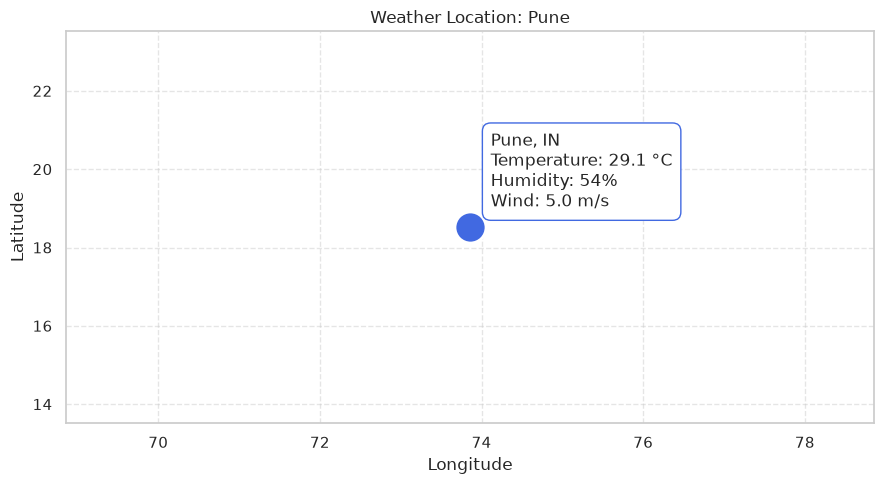

In [29]:
# Create a simple annotated geographical visualization
latest = df.sort_values("datetime").iloc[-1]
latitude = location["coord"]["lat"]
longitude = location["coord"]["lon"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(longitude, latitude, s=500, color="royalblue", edgecolor="white", linewidth=2)
ax.annotate(
    f"{location['name']}, {location['country']}\n"
    f"Temperature: {latest['temperature']:.1f} °C\n"
    f"Humidity: {latest['humidity']:.0f}%\n"
    f"Wind: {latest['wind_speed']:.1f} m/s",
    xy=(longitude, latitude),
    xytext=(15, 15),
    textcoords="offset points",
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "edgecolor": "royalblue"}
)

ax.set_title(f"Weather Location: {location['name']}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(longitude - 5, longitude + 5)
ax.set_ylim(latitude - 5, latitude + 5)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("weather_location_map.png", dpi=150)
plt.show()